In [115]:
import pandas as pd
from scipy.special import comb
import math


def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.))
    probs = [comb(n_classifier, k) *
             error ** k *
             (1 - error) ** (n_classifier - k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)


ensemble_error(n_classifier=11, error=0.25)

np.float64(0.03432750701904297)

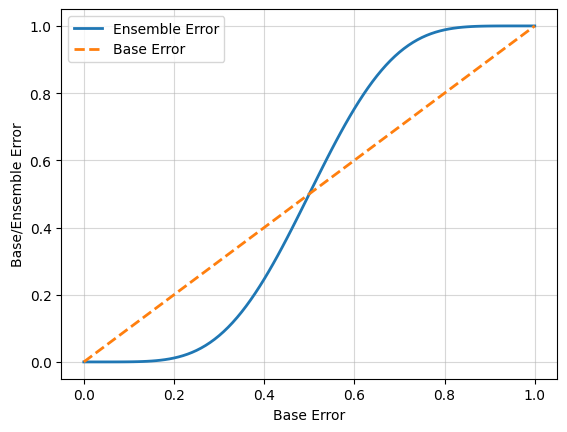

In [116]:
import numpy as np
import matplotlib.pyplot as plt

error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(n_classifier=11, error=error)
              for error in error_range]
plt.plot(error_range, ens_errors, label='Ensemble Error',
         linewidth=2)
plt.plot(error_range, error_range, label='Base Error',
         linestyle='--', linewidth=2)
plt.xlabel('Base Error')
plt.ylabel('Base/Ensemble Error')
plt.legend(loc='best')
plt.grid(alpha=0.5)
plt.show()

In [117]:
np.argmax(np.bincount([0, 0, 1],
                      weights=[0.2, 0.3, 0.6]))

np.int64(1)

In [118]:
ex = np.array([[0.9, 0.1],
               [0.8, 0.2],
               [0.4, 0.6]])
p = np.average(ex, axis=0, weights=[0.2, 0.2, 0.6])
print(p)
np.argmax(p)

[0.58 0.42]


np.int64(0)

In [119]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import _name_estimators
import operator


class MajorityVoteClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, classifiers, vote='classlabel', weights=None):
        self.classifiers = classifiers
        self.named_classifiers = {
            key: value for key, value
            in _name_estimators(classifiers)
        }
        self.vote = vote
        self.weights = weights

    def fit(self, X, y):
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f'Vote must be either "probability" or'
                             f' "classlabel"; got {self.vote}')
        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(
                f'Weights must have the same length as classifiers;'
                f' got {len(self.weights)} weights '
                f'and {len(self.classifiers)} classifiers ')
        self.labelenc_ = LabelEncoder()
        self.labelenc_.fit(y)
        self.classes_ = self.labelenc_.classes_
        self.classifiers_ = []

        for classifier in self.classifiers:
            fitted_clf = clone(classifier).fit(X,
                                               self.labelenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self

    def predict(self, X):
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:
            predictions = np.asarray([
                clf.predict(X) for clf in self.classifiers_
            ]).T

            maj_vote = np.apply_along_axis(
                lambda x: np.argmax(
                    np.bincount(x, weights=self.weights)
                ),
                axis=1, arr=predictions
            )
        maj_vote = self.labelenc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):
        probas = np.asarray([clf.predict_proba(X)
                             for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0,
                               weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in self.named_classifiers.items():
                for key, value in step.get_params(
                        deep=True
                ).items():
                    out[f'{name}__{key}'] = value
            return out

In [120]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5,
                                                    stratify=y, random_state=1)


In [121]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

clf1 = LogisticRegression(l1_ratio=0, solver='lbfgs',
                          C=0.001, random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, random_state=0,
                              criterion='entropy')
clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric='minkowski')
pipe1 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf1]])
pipe3 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf3]])
clf_labels = ['Логистическая регрессия', 'Дерево решений', 'KNN']
print('10-кратная перекрестная проверка:\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf, X=X_train,
                             y=y_train, cv=10, scoring='roc_auc')
    print(f"ROC AUC: {scores.mean():.2f}"
          f"(+/- {scores.std():.2f}) [{label}]")

10-кратная перекрестная проверка:

ROC AUC: 0.92(+/- 0.15) [Логистическая регрессия]
ROC AUC: 0.87(+/- 0.18) [Дерево решений]
ROC AUC: 0.85(+/- 0.13) [KNN]


In [122]:
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])
clf_labels += ['Мажоритарное голосование']
all_clf = [pipe1, clf2, pipe3, mv_clf]
for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc',
                             error_score='raise')
    print(f"ROC AUC: {scores.mean():.2f}"
          f"(+/- {scores.std():.2f}) [{label}]")

ROC AUC: 0.92(+/- 0.15) [Логистическая регрессия]
ROC AUC: 0.87(+/- 0.18) [Дерево решений]
ROC AUC: 0.85(+/- 0.13) [KNN]
ROC AUC: 0.98(+/- 0.05) [Мажоритарное голосование]


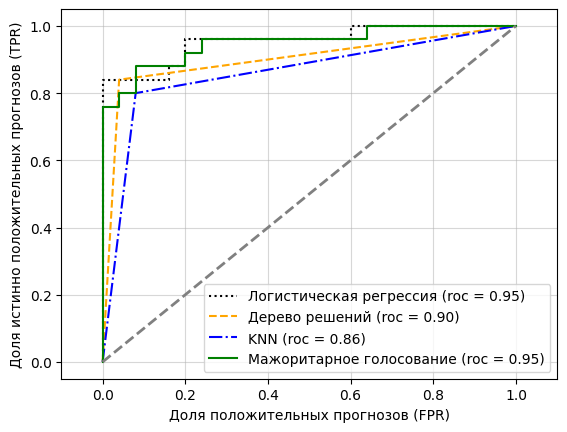

In [123]:
from sklearn.metrics import roc_curve, auc

colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']
for clf, label, clr, ls \
        in zip(all_clf, clf_labels, colors, linestyles):
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test,
                                     y_score=y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=clr, linestyle=ls, label=f'{label} (roc = {roc_auc:.2f})')
plt.legend(loc='best')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray')
plt.xlim([-0.1, 1.1])
plt.xlim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('Доля положительных прогнозов (FPR)')
plt.ylabel('Доля истинно положительных прогнозов (TPR)')
plt.show()

In [124]:
from sklearn.datasets import load_wine
import pandas as pd
wine = load_wine()
df_wine = pd.DataFrame(wine.data,  columns=wine.feature_names)
df_wine['target'] = wine.target
df_wine = df_wine[df_wine['target'] != 0]
X = df_wine[['alcohol', 'od280/od315_of_diluted_wines' ]]
y = df_wine['target']

In [125]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1,
                                                    test_size=0.2, stratify=y)
X_train, X_test = X_train.to_numpy(), X_test.to_numpy()

In [126]:
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier(max_depth=None, random_state=1, criterion='entropy')
bag = BaggingClassifier(estimator=tree, random_state=1, n_estimators=500,
                        max_samples=1., max_features=1., bootstrap=True,
                        bootstrap_features=False, n_jobs=1)

In [127]:
from sklearn.metrics import accuracy_score

tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Toчнocть при обучении и тестировании  {tree_train:.3f}/{tree_test:.3f}')

Toчнocть при обучении и тестировании  1.000/0.833


In [128]:
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)
print(f'Toчнocть при обучении и тестировании  {bag_train:.3f}/{bag_test:.3f}')


Toчнocть при обучении и тестировании  1.000/0.917


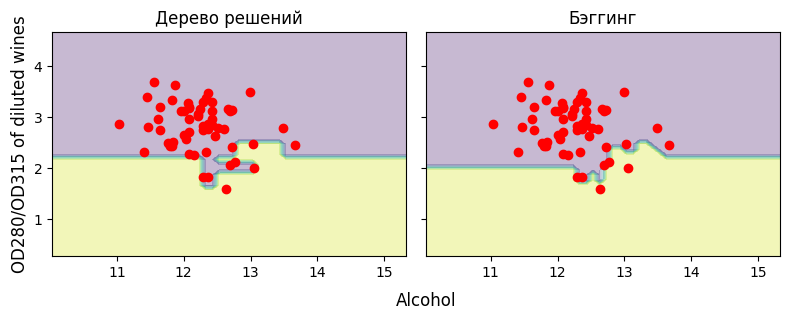

In [129]:
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
f, axarr = plt.subplots(nrows=1, ncols=2,
                        sharex='col', sharey='row',
                        figsize=(8, 3))
for idx, clf, tt in zip([0, 1], [tree, bag], ['Дерево решений', 'Бэггинг']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
                       c='blue',marker='^')
    axarr[idx].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
                       c='red',marker='o')
    axarr[idx].set_title(tt)
axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)
plt.tight_layout()
plt.text(0, -0.2, s='Alcohol',ha='center',
         va='center', fontsize=12, transform=axarr[1].transAxes)
plt.show()

In [133]:
from sklearn.ensemble import AdaBoostClassifier
tree = DecisionTreeClassifier(criterion='entropy', random_state=1,
                              max_depth=2)
ada = AdaBoostClassifier(estimator=tree, random_state=1,
                         n_estimators=500, learning_rate=0.1)
tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Toчнocть при обучении и тестировании  {tree_train:.3f}/{tree_test:.3f}')


Toчнocть при обучении и тестировании  0.916/0.875


In [134]:
ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)
print(f'Toчнocть при обучении и тестировании  {ada_train:.3f}/{ada_test:.3f}')

Toчнocть при обучении и тестировании  1.000/0.917
